# Question 1 Random Forest: Full Trait Model

This notebook evaluates the custom CSC 466 random forest using `data/processed/breed_forest_full.csv`.

This version keeps each AKC trait rating as its own predictor, while `Coat Type` and `Coat Length` remain categorical.

In [1]:
from pathlib import Path
import sys

from sklearn.metrics import classification_report

for base_dir in [Path.cwd(), *Path.cwd().parents]:
    if (base_dir / "data").exists() and (base_dir / "models").exists():
        PROJECT_ROOT = base_dir
        break
else:
    raise FileNotFoundError("Could not find project root with data/ and models/ folders.")

sys.path.insert(0, str(PROJECT_ROOT))

from models.randomForest.gridSearch import build_rf, run_grid_search
from models.randomForest.rf_analysis_utils import (
    LABEL_ORDER,
    collect_split_counts,
    feature_profiles,
    load_train_test_data,
    make_prediction_results,
    plot_confusion,
)

In [2]:
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "breed_forest_full.csv"
GRID_PATH = PROJECT_ROOT / "models" / "randomForest" / "rf_grid_search_params.csv"
PREDICTION_OUTPUT_PATH = PROJECT_ROOT / "results" / "question1" / "rf_test_predictions.csv"

best_params = run_grid_search(DATA_PATH, GRID_PATH)

In [3]:
X, y, attributes, X_train, X_test, y_train, y_test = load_train_test_data(DATA_PATH)

## Final Test Results

The model is trained on the training split using the best cross-validation parameters, then evaluated on the held-out test split. Macro F1 is useful here because the three popularity tiers are not perfectly balanced.

In [4]:
best_rf = build_rf(best_params, seed=42)
best_rf.fit(X_train, y_train, attributes)
test_predictions = best_rf.predict(X_test)

## Model Interpretation

These tables show which features the forest split on most often and how average feature values differ across the actual popularity tiers.

In [5]:
split_importance = collect_split_counts(best_rf.forest)
split_importance

,Feature,Split Count
0,Adaptability Level,18
1,Barking Level,13
2,Watchdog/Protective Nature,12
3,Openness To Strangers,12
4,Good With Other Dogs,11
5,Coat Grooming Frequency,8
6,Energy Level,7
7,Good With Young Children,6
8,Shedding Level,6
9,Playfulness Level,5


In [6]:
trait_profile, category_profile = feature_profiles(X, y, LABEL_ORDER)
trait_profile

Popularity_Tier,High Popularity,Medium Popularity,Low Popularity
Affectionate With Family,4.55,4.51,4.47
Good With Young Children,4.18,3.73,3.71
Good With Other Dogs,3.57,3.45,3.62
Shedding Level,2.74,2.62,2.41
Coat Grooming Frequency,2.42,2.28,2.11
Drooling Level,1.95,1.76,1.61
Openness To Strangers,3.66,3.51,3.29
Playfulness Level,3.88,3.68,3.41
Watchdog/Protective Nature,3.78,3.82,3.55
Adaptability Level,3.92,3.77,3.65


In [7]:
category_profile

,Coat Type,Coat Length
Popularity_Tier,,
High Popularity,Smooth,Short
Medium Popularity,Smooth,Short
Low Popularity,Double,Medium


In [8]:
print(classification_report(y_test, test_predictions, labels=LABEL_ORDER, zero_division=0))

                   precision    recall  f1-score   support

  High Popularity       0.22      0.15      0.18        13
Medium Popularity       0.00      0.00      0.00        15
   Low Popularity       0.31      0.77      0.44        13

         accuracy                           0.29        41
        macro avg       0.18      0.31      0.21        41
     weighted avg       0.17      0.29      0.20        41



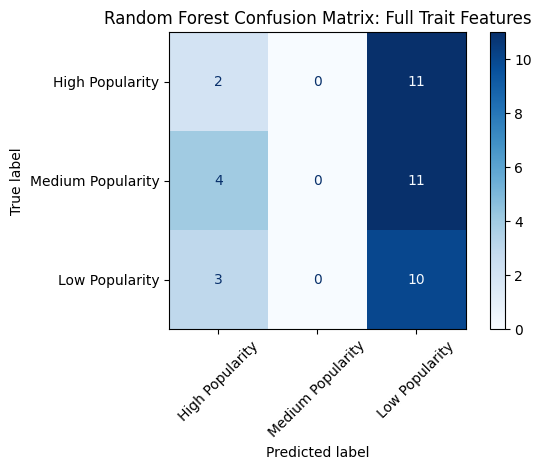

In [9]:
plot_confusion(y_test, test_predictions, "Random Forest Confusion Matrix: Full Trait Features")

## Prediction CSV

This output compares each test-set breed's actual popularity tier to the tier predicted by the full-trait random forest model. `Average Rank` is included for interpretation only; it is not used as a predictor.

In [10]:
PREDICTION_OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)

prediction_results = make_prediction_results(
    DATA_PATH,
    PROJECT_ROOT / "data" / "interim" / "breed_ranks.csv",
    X_test,
    y_test,
    test_predictions,
)

prediction_results.to_csv(PREDICTION_OUTPUT_PATH, index=False)
prediction_results

,Breed,Average Rank,Actual Popularity Tier,Predicted Popularity Tier,Correct
0,Bloodhound,51.2,High Popularity,Low Popularity,False
1,Dogue de Bordeaux,73.2,Medium Popularity,High Popularity,False
2,Irish Water Spaniel,163.6,Low Popularity,Low Popularity,True
3,Anatolian Shepherd Dog,87.9,Medium Popularity,Low Popularity,False
4,Belgian Malinoi,42.2,High Popularity,Low Popularity,False
5,Italian Greyhound,67.2,Medium Popularity,Low Popularity,False
6,Chinese Shar-Pei,65.5,High Popularity,Low Popularity,False
7,Afghan Hound,108.9,Medium Popularity,Low Popularity,False
8,Polish Lowland Sheepdog,175.6,Low Popularity,High Popularity,False
9,Irish Terrier,124.9,Medium Popularity,Low Popularity,False
